In [1]:
import plot
import os
from marl import LightExperiment
from lle import CooperationLevel

all_experiments = [LightExperiment.load(os.path.join("logs", d)) for d in os.listdir("logs") if os.path.isdir(os.path.join("logs", d))]
all_experiments = [e for e in all_experiments if len(list(e.runs)) > 0]

# Plots

## Per cooperation level

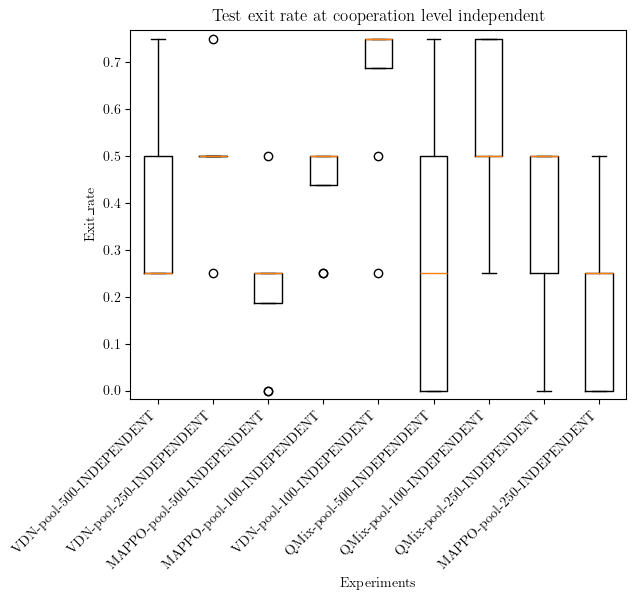

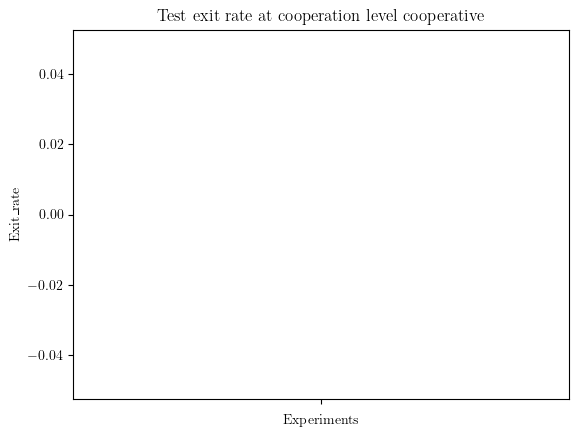

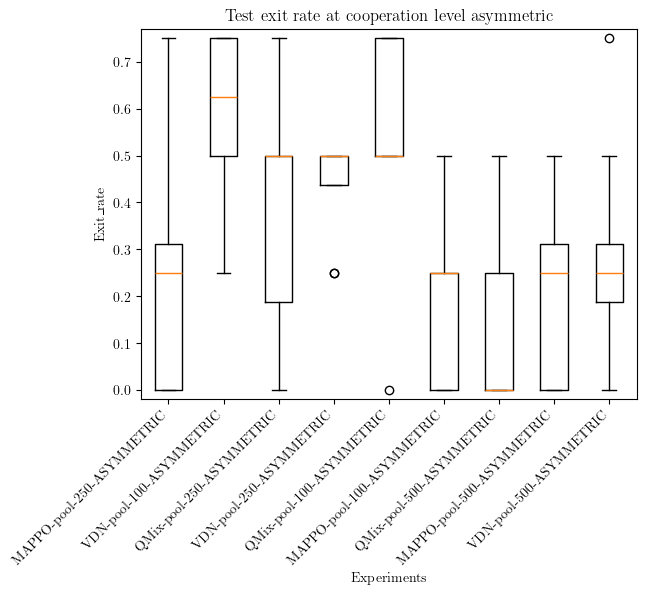

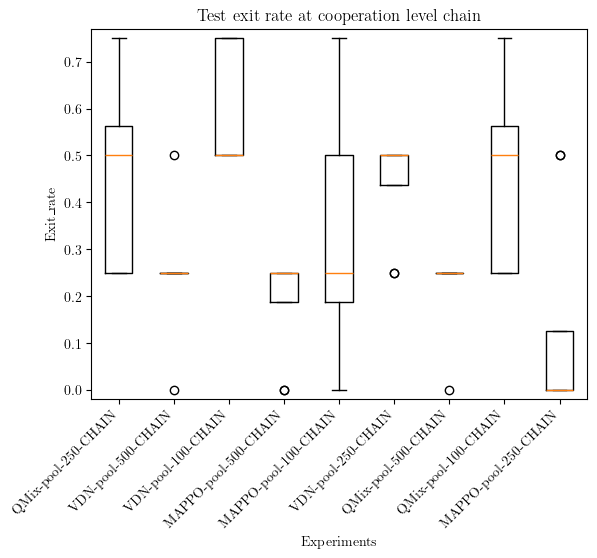

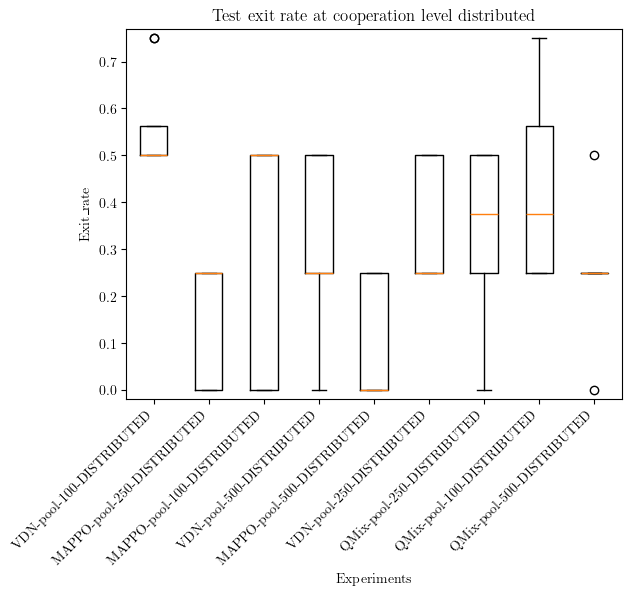

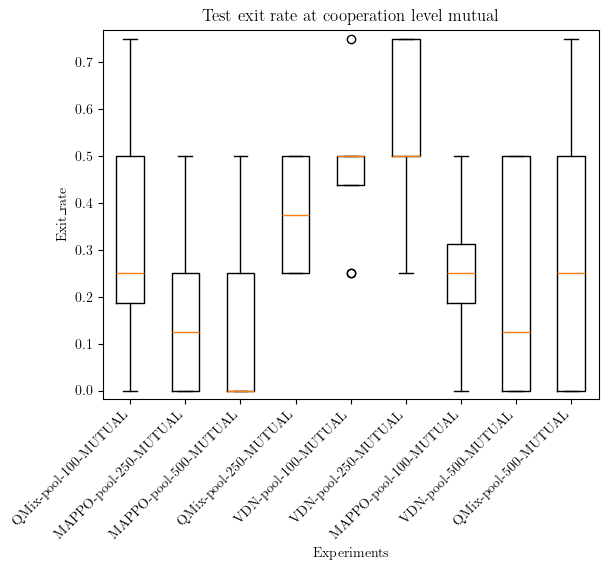

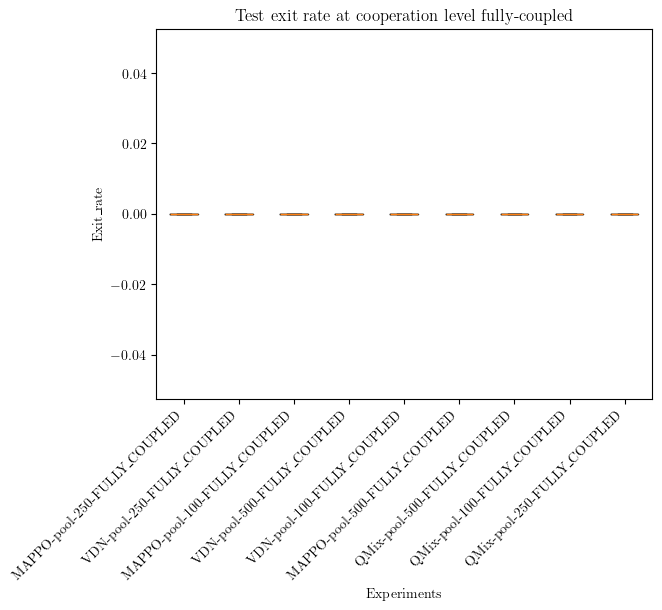

In [2]:
for coop in CooperationLevel:
    experiments = [e for e in all_experiments if coop.name in e.logdir]
    fig, ax = plot.boxplot_at(experiments, "exit_rate", kind="Train")
    ax.set_title(f"Test exit rate at cooperation level {coop.value}")
    fig.savefig(f"train-boxplot-{coop.value}")


## Per size

In [ ]:
for size in ("100", "250", "500"):
    experiments = [e for e in all_experiments if (size in e.logdir)]
    fig, ax = plot.boxplot_at(experiments, "exit_rate")
    ax.set_title(f"Exit rate at size {size}")
    fig.savefig(f"boxplot-{size}")


## Per size and cooperation level

In [ ]:
for size in ("100", "250", "500"):
    for coop in CooperationLevel:
        experiments = [e for e in all_experiments if (size in e.logdir and coop.name in e.logdir)]
        fig, ax = plot.boxplot_at(experiments, "exit_rate")
        ax.set_title(f"Exit rate at size {size} and cooperation level {coop.value}")
        fig.savefig(f"boxplot-{size}-{coop.value}")

CooperationLevel.INDEPENDENT


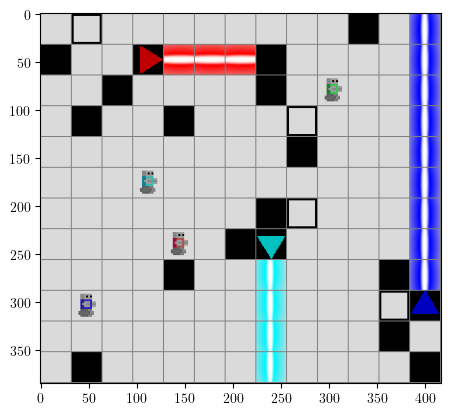

CooperationLevel.ASYMMETRIC


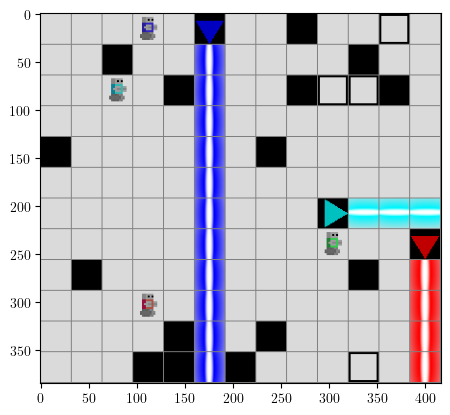

CooperationLevel.CHAIN


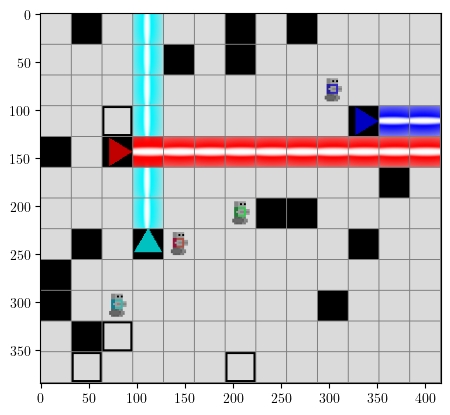

CooperationLevel.DISTRIBUTED


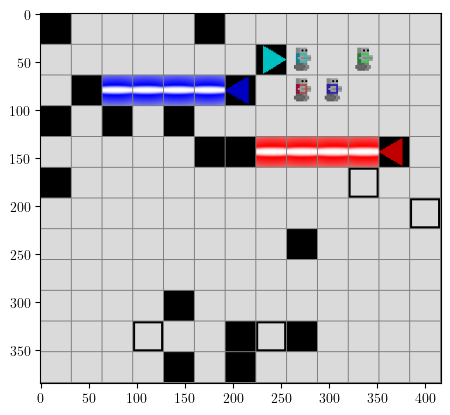

CooperationLevel.MUTUAL


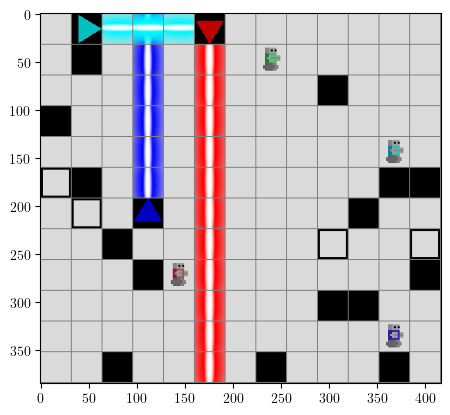

CooperationLevel.FULLY_COUPLED


FileNotFoundError: maps/pool/random/FULLY_COUPLED/0

In [4]:
import lle
import os
import matplotlib.pyplot as plt

for coop in CooperationLevel:
    if coop == CooperationLevel.COOPERATIVE:
        continue
    print(coop)
    world = lle.World.from_file(f"maps/pool/random/{coop.name}/0")
    img = world.get_image()
    plt.imshow(img)
    plt.show()
